# Análise do Comércio Internacional de Roupas Usadas — UN Comtrade

Este notebook apresenta uma análise exploratória dos dados de comércio internacional de roupas usadas, utilizando dados da plataforma UN Comtrade.

O objetivo é identificar:
- a evolução do volume comercializado;
- os principais países exportadores;
- os principais países importadores;
- a relação entre peso e valor das mercadorias.

## 1. Objetivo da análise

Analisar o comércio internacional de roupas usadas e identificar padrões relacionados aos volumes de exportação e importação.

A análise busca contribuir para a compreensão da circulação internacional de roupas usadas e fornecer dados para discutir possíveis impactos relacionados à reutilização, economia circular e geração de resíduos têxteis.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Carregamento dos dados

Foram utilizados dados do UN Comtrade referentes ao comércio internacional de roupas usadas.

Os arquivos utilizados apresentam dados de exportação e importação.

In [3]:
df = pd.read_csv("comtrade_exportacoes_2020_2024.csv", index_col=False)

df_import = pd.read_csv("comtrade_importacoes_2020_2024.csv", index_col=False)

print("Dados de exportação:")
print(df.shape)

print("\nDados de importação:")
print(df_import.shape)

Dados de exportação:
(525, 47)

Dados de importação:
(549, 47)


## 3. Visualização inicial dos dados

Nesta etapa são observadas as primeiras linhas das bases para verificar sua estrutura.

In [4]:
display(df.head())

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20220101,2022,52,2022,20,AND,Andorra,X,...,539996.600,False,0.000000e+00,False,NaN,6.518555e+05,6.518555e+05,0,False,True
1,C,A,20220101,2022,52,2022,24,AGO,Angola,X,...,440797.901,False,0.000000e+00,False,611988.17,6.086453e+05,6.086453e+05,0,False,True
2,C,A,20220101,2022,52,2022,28,ATG,Antigua and Barbuda,X,...,8699.320,False,0.000000e+00,False,NaN,2.321246e+04,2.321246e+04,0,False,True
3,C,A,20220101,2022,52,2022,31,AZE,Azerbaijan,X,...,37751.630,False,0.000000e+00,False,NaN,1.369924e+05,1.369924e+05,0,False,True
4,C,A,20220101,2022,52,2022,36,AUS,Australia,X,...,NaN,False,1.117287e+08,False,NaN,6.525668e+07,6.525668e+07,0,False,True


In [5]:
display(df_import.head())

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20220101,2022,52,2022,8,ALB,Albania,M,...,69.80,False,0.0,False,1.446373e+03,NaN,1.446373e+03,0,False,True
1,C,A,20220101,2022,52,2022,20,AND,Andorra,M,...,529572.28,False,0.0,False,9.718026e+05,NaN,9.718026e+05,0,False,True
2,C,A,20220101,2022,52,2022,24,AGO,Angola,M,...,93139216.98,False,0.0,False,9.120299e+07,78958533.27,9.120299e+07,0,False,True
3,C,A,20220101,2022,52,2022,28,ATG,Antigua and Barbuda,M,...,17402.33,False,0.0,False,2.640783e+04,NaN,2.640783e+04,0,False,True
4,C,A,20220101,2022,52,2022,31,AZE,Azerbaijan,M,...,788460.73,False,0.0,False,2.229819e+06,NaN,2.229819e+06,0,False,True


## 4. Verificação de valores ausentes e registros duplicados

Nesta etapa são identificados valores ausentes e registros duplicados que podem afetar a análise.

In [6]:
print("VALORES AUSENTES — EXPORTAÇÕES:")
print(df[["refYear", "reporterDesc", "netWgt", "primaryValue"]].isnull().sum())

print("\nDUPLICADOS — EXPORTAÇÕES:")
print(df.duplicated().sum())

VALORES AUSENTES — EXPORTAÇÕES:
refYear          0
reporterDesc     0
netWgt          52
primaryValue     0
dtype: int64

DUPLICADOS — EXPORTAÇÕES:
0


In [7]:
print("VALORES AUSENTES — IMPORTAÇÕES:")
print(df_import[["refYear", "reporterDesc", "netWgt", "primaryValue"]].isnull().sum())

print("\nDUPLICADOS — IMPORTAÇÕES:")
print(df_import.duplicated().sum())

VALORES AUSENTES — IMPORTAÇÕES:
refYear          0
reporterDesc     0
netWgt          43
primaryValue     0
dtype: int64

DUPLICADOS — IMPORTAÇÕES:
0


## 5. Tratamento dos dados

As variáveis de ano, peso e valor foram convertidas para formatos numéricos.

Também foi criada uma variável de peso em toneladas para facilitar a interpretação dos resultados.

In [8]:
df["refYear"] = pd.to_numeric(df["refYear"], errors="coerce")
df["netWgt"] = pd.to_numeric(df["netWgt"], errors="coerce")
df["primaryValue"] = pd.to_numeric(df["primaryValue"], errors="coerce")

df["peso_toneladas"] = df["netWgt"] / 1000

In [9]:
df_import["refYear"] = pd.to_numeric(df_import["refYear"], errors="coerce")
df_import["netWgt"] = pd.to_numeric(df_import["netWgt"], errors="coerce")
df_import["primaryValue"] = pd.to_numeric(df_import["primaryValue"], errors="coerce")

df_import["peso_toneladas"] = df_import["netWgt"] / 1000

## 6. Estatísticas descritivas

As estatísticas descritivas permitem observar características gerais dos dados, como média, mínimo, máximo e dispersão.

In [10]:
display(
    df[
        ["netWgt", "peso_toneladas", "primaryValue"]
    ].describe()
)

,netWgt,peso_toneladas,primaryValue
count,4.730000e+02,4.730000e+02,5.250000e+02
mean,3.396290e+07,3.396290e+04,4.011154e+07
std,1.152032e+08,1.152032e+05,1.199777e+08
min,0.000000e+00,0.000000e+00,7.010000e-01
25%,3.600888e+04,3.600888e+01,8.207483e+04
50%,7.735480e+05,7.735480e+02,9.594760e+05
75%,1.507161e+07,1.507161e+04,1.829048e+07
max,1.370381e+09,1.370381e+06,9.937118e+08


## 7. Volume de exportações por ano

Nesta etapa é analisada a evolução do volume de roupas usadas exportadas ao longo dos anos disponíveis na base.

In [11]:
volume_ano = (
    df.groupby("refYear")["peso_toneladas"]
    .sum()
    .reset_index()
)

display(volume_ano)

,refYear,peso_toneladas
0,2022,3.040516e+06
1,2023,3.914180e+06
2,2024,5.046706e+06
3,2025,4.063051e+06


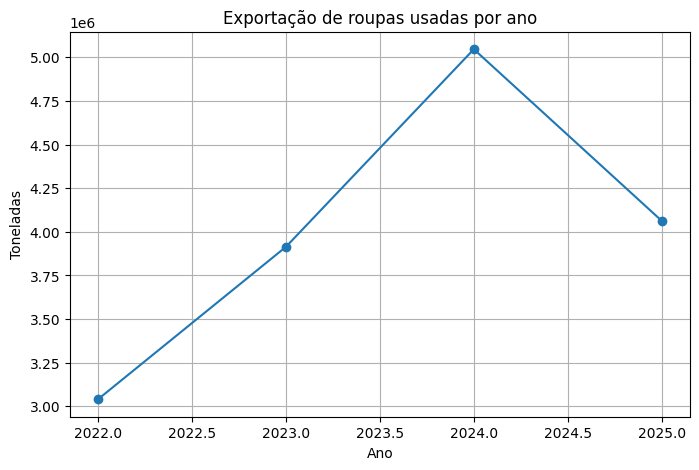

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    volume_ano["refYear"],
    volume_ano["peso_toneladas"],
    marker="o"
)

plt.title("Exportação de roupas usadas por ano")
plt.xlabel("Ano")
plt.ylabel("Toneladas")
plt.grid(True)

plt.show()

## 8. Volume de importações por ano

A mesma análise é realizada para os dados de importação, permitindo observar a evolução da entrada de roupas usadas nos países registrados na base.

In [14]:
volume_importacao = (
    df_import.groupby("refYear")["peso_toneladas"]
    .sum()
    .reset_index()
)

display(volume_importacao)

,refYear,peso_toneladas
0,2022,4.650771e+06
1,2023,5.046531e+06
2,2024,4.458014e+06
3,2025,2.493921e+06


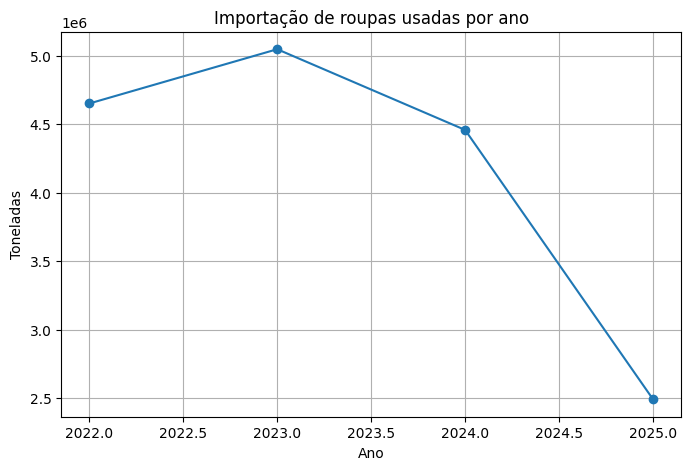

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    volume_importacao["refYear"],
    volume_importacao["peso_toneladas"],
    marker="o"
)

plt.title("Importação de roupas usadas por ano")
plt.xlabel("Ano")
plt.ylabel("Toneladas")
plt.grid(True)

plt.show()

## 9. Principais países exportadores

Nesta etapa são identificados os países que apresentaram os maiores volumes acumulados de exportação de roupas usadas no período analisado.

In [16]:
top_exportadores = (
    df.groupby("reporterDesc")["peso_toneladas"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(top_exportadores)

,peso_toneladas
reporterDesc,
China,3.841720e+06
Germany,1.301483e+06
Rep. of Korea,1.207325e+06
Pakistan,1.190165e+06
Poland,6.885174e+05
USA,6.737262e+05
Netherlands,6.677060e+05
Canada,4.688766e+05
Spain,4.334906e+05


## 10. Principais países importadores

São identificados os países que apresentaram os maiores volumes acumulados de importação de roupas usadas.

In [17]:
top_importadores = (
    df_import.groupby("reporterDesc")["peso_toneladas"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(top_importadores)

,peso_toneladas
reporterDesc,
Pakistan,2.757662e+06
Kenya,8.556811e+05
United Arab Emirates,8.323721e+05
India,7.577528e+05
Malaysia,6.932586e+05
Guatemala,5.449550e+05
Thailand,4.653554e+05
Uganda,3.824277e+05
Benin,3.570558e+05


## 11. Relação entre peso e valor

A correlação entre o peso das mercadorias e seu valor comercial é analisada para verificar se existe associação entre essas duas variáveis.

A correlação não significa necessariamente causalidade.

In [18]:
correlacao_importacoes = (
    df_import[["peso_toneladas", "primaryValue"]]
    .corr()
)

display(correlacao_importacoes)

,peso_toneladas,primaryValue
peso_toneladas,1.000000,0.876013
primaryValue,0.876013,1.000000


## 12. Principais resultados

A análise do UN Comtrade permite observar um comércio internacional de roupas usadas em escala de milhões de toneladas.

Entre os principais resultados estão:

1. O volume de exportações apresentou crescimento entre 2022 e 2024.
2. Em 2025 houve redução em relação a 2024, embora o volume tenha permanecido superior ao observado em 2022.
3. O comércio apresenta concentração em determinados países exportadores.
4. Alguns países concentram grandes volumes de importação.
5. O volume comercializado não significa automaticamente que as roupas tenham sido descartadas como resíduos, pois os dados de comércio não informam diretamente o destino final de cada peça.

Esses resultados serão relacionados posteriormente aos dados da EEA e do Eurostat.